In [1]:
import logging
import sys
from pathlib import Path
import pandas as pd
import joblib


logging.basicConfig(
    format="%(asctime)s.%(msecs)d %(levelname)s %(filename)s:%(lineno)d %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger()
logger.setLevel(logging.INFO)


# Move up one level from scripts/ to find the project root
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

logging.info(f"Project root added to path: {PROJECT_ROOT}")

from src.core.dataset_parser import parse_claudette_zipfile
from src.core.feature_engine import SimpleEmbeddingEngine
from src.core.classifier import ClauseClassifier, MODELS_TO_EXPERIMENT




20:41:10.390 INFO 1351323694.py:21 Project root added to path: /home/miguel/enhesa-tos-service
/home/miguel/.cache/pypoetry/virtualenvs/enhesa-tos-service-eiCNO2e5-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
models_output_dir = PROJECT_ROOT / "models" / "classifiers"
artifacts_dir = PROJECT_ROOT / "models" / "search_artifacts"
zip_filepath = PROJECT_ROOT / "data" / "ToS.zip"


In [3]:
logging.info(f"Fetching raw data from {zip_filepath}& parsing...")
labeled_sentences_df=parse_claudette_zipfile(zip_filepath)


20:41:15.697 INFO 1496314955.py:1 Fetching raw data from /home/miguel/enhesa-tos-service/data/ToS.zip& parsing...
20:41:15.703 INFO dataset_parser.py:54 Getting all files in zip...
20:41:15.704 INFO dataset_parser.py:58 Getting all sentence files in zip...
20:41:15.705 INFO dataset_parser.py:65 looping all sentence files from all companies...
20:41:15.705 INFO dataset_parser.py:72 Processing company Fitbit...
20:41:15.706 INFO dataset_parser.py:74 Extracting all sentences...
20:41:15.708 INFO dataset_parser.py:81 Extracting all corresponding labels for is_unfair...
20:41:15.709 INFO dataset_parser.py:81 Extracting all corresponding labels for arbitration...
20:41:15.711 INFO dataset_parser.py:81 Extracting all corresponding labels for unilateral_change...
20:41:15.712 INFO dataset_parser.py:81 Extracting all corresponding labels for content_removal...
20:41:15.713 INFO dataset_parser.py:81 Extracting all corresponding labels for jurisdiction...
20:41:15.713 INFO dataset_parser.py:81 Ex

In [5]:
labeled_sentences_df['is_unfair'].unique()

array([0, 1])

In [9]:
logging.info("Instantiate a fresh engine instance")
search_engine = SimpleEmbeddingEngine()

logging.info(f"Loading precomputed embeddings from {artifacts_dir}...")
search_engine.load_artifacts(artifacts_dir)


logging.info("Loading Champion Neural Network Weights (MLPClassifier)...")
clause_clf = ClauseClassifier()
mlp_model_dir = PROJECT_ROOT / "models" / "classifiers" / "MLPClassifier"
clause_clf.load_model(mlp_model_dir)

    

20:04:27.117 INFO 3988157149.py:1 Instantiate a fresh engine instance
20:04:27.118 INFO feature_engine.py:20 Loading SentenceTransformer vector mapping space: all-MiniLM-L6-v2
20:04:27.119 INFO model.py:190 No device provided, using cpu
20:04:27.308 INFO _client.py:1025 HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
20:04:27.332 INFO _client.py:1025 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
20:04:27.473 INFO _client.py:1025 HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
20:04:27.496 INFO _client.py:1025 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41

<Axes: >

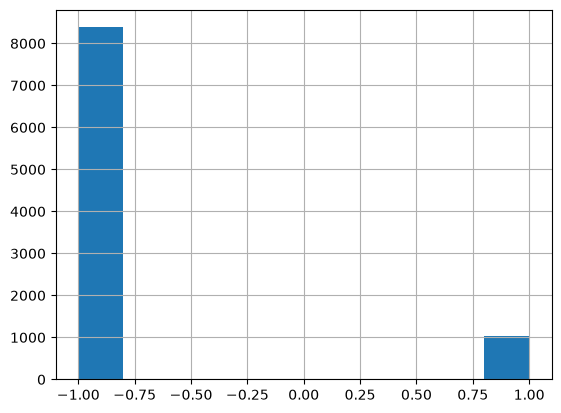

In [10]:
search_engine.metadata_df['is_unfair'].hist()

In [11]:

def process_user_sentence(input_sentence: str, top_k: int=3):

    print(f"\n👉 Input Clause: '{input_sentence}'")

    search_results = search_engine.search(input_sentence, top_k=top_k)

    for rank, match in enumerate(search_results, 1):
            print(f"\nMatch #{rank} (Similarity Score: {match['similarity_score']:.4f})")
            print(f"🏢 Company: {match.get('company', 'Unknown')}")
            print(f"📜 Text: \"{match.get('text')}\"")
            print(f"📊 Historical Ground Truth: {'🚨 Unfair' if match.get('is_unfair') == 1 else '✅ Fair'}")    

    # ========================================================
    # Requirement 2: Classification (Detect Unfair Clauses)
    # ========================================================
    print("\n--- 🧠 REQUIREMENT 2: CLASSIFICATION ANALYSIS ---")

    # Mirroring exactly what build_index does under the hood for a single query text
    query_vector = search_engine.transform(input_sentence)

    # Hand the resulting X predictor array straight to the loaded MLP
    prediction = clause_clf.predict(query_vector)

    # Fetch probability metrics if you want confidence intervals
    try:
        prob = clause_clf.model.predict_proba(query_vector)[0][1]
        print(f"System Confidence: {prob * 100:.2f}% risk probability")
    except AttributeError:
        pass

    if prediction == 1:
        print("🚨 FLAG STATUS: HIGH RISK / UNFAIR CLAUSE DETECTED")
    else:
        print("✅ FLAG STATUS: LOW RISK / COMPLIANT")


In [15]:
# 2. Hardcoded test suite with texts paired with their target/expected behaviors
evaluation_suite = [
{
        "text": "We may change, suspend, or terminate your access to the platform at our sole discretion, for any reason or no reason, without notice or liability to you.",
        "category": "Blatantly Unfair",
        "expected_status": "🚨 UNFAIR (High Risk)",
        "rationale": "Classic unconscionable unilateral termination pattern."
},
{
        "text": "You agree to indemnify and hold harmless the company from any and all claims, damages, or losses, including those resulting entirely from the company's own negligence.",
        "category": "Blatantly Unfair",
        "expected_status": "🚨 UNFAIR (High Risk)",
        "rationale": "Predatory shifting of direct corporate negligence onto the user."
},
{
        "text": "Either party may terminate this agreement upon 30 days written notice if the other party materially breaches any provision herein.",
        "category": "Fair / Standard Boilerplate",
        "expected_status": "✅ FAIR (Low Risk)",
        "rationale": "Bilateral/mutual termination right linked to an explicit material breach."
},
{
        "text": "The company will provide users with at least 14 days' advance notice via email before implementing any material changes to these terms.",
        "category": "Fair / Standard Boilerplate",
        "expected_status": "✅ FAIR (Low Risk)",
        "rationale": "Fair notice period safeguards user awareness before changes go live."
},
{
        "text": "Except as expressly provided otherwise in this agreement, all notices must be given in writing and sent via certified mail to the registered address.",
        "category": "Fair / Standard Boilerplate",
        "expected_status": "✅ FAIR (Low Risk)",
        "rationale": "Purely mechanical administrative clause with zero power skew."
},
{
        "text": "While we look forward to a lasting relationship, we reserve the right to end this partnership at any time, but we promise to try our best to let you know beforehand if we do.",
        "category": "Semantic Edge Case",
        "expected_status": "🚨 UNFAIR (High Risk)",
        "rationale": "Polite tone hides a dangerous loophole ('trying' to notify is not a legal obligation)."
},
{
        "text": "In no event shall either party be liable to the other for any indirect, incidental, special, or consequential damages arising out of this agreement.",
        "category": "Semantic Edge Case",
        "expected_status": "✅ FAIR (Low Risk)",
        "rationale": "Contains high-risk jargon but enforces liability limits evenly across both sides."
},
{
        "text": "The user agrees that any data uploaded to the server becomes the sole and exclusive intellectual property of the platform, and the platform may sell or monetize it without compensating the user.",
        "category": "Semantic Edge Case",
        "expected_status": "🚨 UNFAIR (High Risk)",
        "rationale": "Predatory IP asset extraction without equity or compensation."
},
{
        "text": "This agreement shall automatically renew for successive one-year terms unless either party gives written notice of non-renewal at least 60 days prior to the end of the current term.",
        "category": "Semantic Edge Case",
        "expected_status": "✅ FAIR (Low Risk)",
        "rationale": "Standard evergreen clause offering transparent opt-out rules for both parties."
}
]

# 3. Execution sweep over the test cases
for idx, case in enumerate(evaluation_suite, 1):
        clause_text = case["text"]
        process_user_sentence(clause_text)

        print(f"Expected Outcome: {case['expected_status']}")
        print("="*20)


👉 Input Clause: 'We may change, suspend, or terminate your access to the platform at our sole discretion, for any reason or no reason, without notice or liability to you.'


Batches: 100%|██████████| 1/1 [00:00<00:00, 14.01it/s]



Match #1 (Similarity Score: 0.7842)
🏢 Company: WhatsApp
📜 Text: "we may modify , suspend , or terminate your access to or use of our services anytime for any reason , such as if you violate the letter or spirit of our terms or create harm , risk , or possible legal exposure for us , our users , or others ."
📊 Historical Ground Truth: 🚨 Unfair

Match #2 (Similarity Score: 0.7356)
🏢 Company: Masquerade
📜 Text: "we may suspend , or terminate your access to or use of our services anytime for any reason , such as if you violate the letter or spirit of our terms and polices , or create harm , risk , or possible legal exposure for us , our users , or others ."
📊 Historical Ground Truth: 🚨 Unfair

Match #3 (Similarity Score: 0.7216)
🏢 Company: Betterpoints_UK
📜 Text: "we may , in our sole discretion , terminate or suspend your access to all or part of the service at any time , with or without notice , for any reason , including , without limitation , breach of this agreement ."
📊 Historical G

Batches: 100%|██████████| 1/1 [00:00<00:00,  7.34it/s]


System Confidence: 99.87% risk probability
🚨 FLAG STATUS: HIGH RISK / UNFAIR CLAUSE DETECTED
Expected Outcome: 🚨 UNFAIR (High Risk)

👉 Input Clause: 'You agree to indemnify and hold harmless the company from any and all claims, damages, or losses, including those resulting entirely from the company's own negligence.'


...

System Confidence: 0.00% risk probability
✅ FLAG STATUS: LOW RISK / COMPLIANT
Expected Outcome: 🚨 UNFAIR (High Risk)

👉 Input Clause: 'This agreement shall automatically renew for successive one-year terms unless either party gives written notice of non-renewal at least 60 days prior to the end of the current term.'


Batches: 100%|██████████| 1/1 [00:00<00:00, 20.31it/s]



Match #1 (Similarity Score: 0.6607)
🏢 Company: Dropbox
📜 Text: "if you 're on an annual plan , we 'll send you a notice email reminding you that your plan is about to renew within a reasonable period of time prior to the renewal date ."
📊 Historical Ground Truth: ✅ Fair

Match #2 (Similarity Score: 0.6423)
🏢 Company: eBay
📜 Text: "we will provide you 30 days ' notice by posting the amended terms ."
📊 Historical Ground Truth: ✅ Fair

Match #3 (Similarity Score: 0.6368)
🏢 Company: Vimeo
📜 Text: "renewals : subject to the terms hereof , you may choose to renew your subscription at the end of the subscription period ."
📊 Historical Ground Truth: ✅ Fair

--- 🧠 REQUIREMENT 2: CLASSIFICATION ANALYSIS ---


Batches: 100%|██████████| 1/1 [00:00<00:00,  7.38it/s]

System Confidence: 0.00% risk probability
✅ FLAG STATUS: LOW RISK / COMPLIANT
Expected Outcome: ✅ FAIR (Low Risk)


In [18]:
import numpy as np

# 1. Setup Dataset Priors (Assuming roughly a 15% unfair clause baseline in the dataset)
PRIOR_UNFAIR = 0.15
PRIOR_FAIR = 1.0 - PRIOR_UNFAIR
TOP_K_NEIGHBORS = 5

# 2. Hardcoded test suite
evaluation_suite = [
    {
        "text": "We may change, suspend, or terminate your access to the platform at our sole discretion, for any reason or no reason, without notice or liability to you.",
        "category": "Blatantly Unfair",
        "expected_status": "🚨 UNFAIR (High Risk)"
    },
    {
        "text": "You agree to indemnify and hold harmless the company from any and all claims, damages, or losses, including those resulting entirely from the company's own negligence.",
        "category": "Blatantly Unfair",
        "expected_status": "🚨 UNFAIR (High Risk)"
    },
    {
        "text": "Any disputes arising from this agreement shall be governed by the laws of the Cayman Islands, and you waive any right to a jury trial or to participate in a class-action lawsuit.",
        "category": "Blatantly Unfair",
        "expected_status": "🚨 UNFAIR (High Risk)"
    },
    {
        "text": "Either party may terminate this agreement upon 30 days written notice if the other party materially breaches any provision herein.",
        "category": "Fair / Standard Boilerplate",
        "expected_status": "✅ FAIR (Low Risk)"
    },
    {
        "text": "The company will provide users with at least 14 days' advance notice via email before implementing any material changes to these terms.",
        "category": "Fair / Standard Boilerplate",
        "expected_status": "✅ FAIR (Low Risk)"
    },
    {
        "text": "Except as expressly provided otherwise in this agreement, all notices must be given in writing and sent via certified mail to the registered address.",
        "category": "Fair / Standard Boilerplate",
        "expected_status": "✅ FAIR (Low Risk)"
    },
    {
        "text": "While we look forward to a lasting relationship, we reserve the right to end this partnership at any time, but we promise to try our best to let you know beforehand if we do.",
        "category": "Semantic Edge Case",
        "expected_status": "🚨 UNFAIR (High Risk)"
    },
    {
        "text": "In no event shall either party be liable to the other for any indirect, incidental, special, or consequential damages arising out of this agreement.",
        "category": "Semantic Edge Case",
        "expected_status": "✅ FAIR (Low Risk)"
    },
    {
        "text": "The user agrees that any data uploaded to the server becomes the sole and exclusive intellectual property of the platform, and the platform may sell or monetize it without compensating the user.",
        "category": "Semantic Edge Case",
        "expected_status": "🚨 UNFAIR (High Risk)"
    },
    {
        "text": "This agreement shall automatically renew for successive one-year terms unless either party gives written notice of non-renewal at least 60 days prior to the end of the current term.",
        "category": "Semantic Edge Case",
        "expected_status": "✅ FAIR (Low Risk)"
    }
]

# 3. Execution sweep over the test cases
for idx, case in enumerate(evaluation_suite, 1):
    clause_text = case["text"]
    
    print("\n" + "="*80)
    print(f"👉 TEST CASE #{idx} [{case['category']}]")
    print(f"Clause: \"{clause_text}\"")
    print("="*80)

    # Step A: Extract Vector Neighborhood Behavior
    search_results = search_engine.search(clause_text, top_k=TOP_K_NEIGHBORS)
    
    unfair_matches = sum(1 for m in search_results if int(m.get('is_unfair', 0)) == 1)
    neighborhood_risk = unfair_matches / TOP_K_NEIGHBORS
    
    print("\n--- 🔍 NEAREST HISTORICAL MATCHES ---")
    for rank, match in enumerate(search_results, 1):
        match_flag = "🚨 Unfair" if int(match.get('is_unfair', 0)) == 1 else "✅ Fair"
        print(f" #{rank} [Sim: {match['similarity_score']:.4f}] -> {match_flag} ({match.get('company')})")

    # Step B: Extract MLP Base Probabilities
    X_query = search_engine.transform(clause_text)
    try:
        mlp_prob = clause_clf.model.predict_proba(X_query)[0][1]
    except AttributeError:
        mlp_prob = 0.5
        
    # Step C: Simple Bayesian Fusion Logic
    # Soften absolute 0/1 metrics to keep multiplication from zeroing out fields
    p_mlp_unfair = np.clip(mlp_prob, 0.01, 0.99)
    p_mlp_fair = 1.0 - p_mlp_unfair
    
    p_neigh_unfair = np.clip(neighborhood_risk, 0.05, 0.95)
    p_neigh_fair = 1.0 - p_neigh_unfair
    
    # Calculate Bayesian updating numerator and denominator
    unfair_likelihood = PRIOR_UNFAIR * p_mlp_unfair * p_neigh_unfair
    fair_likelihood = PRIOR_FAIR * p_mlp_fair * p_neigh_fair
    
    # Normalize to get final posterior probability
    bayesian_final_prob = unfair_likelihood / (unfair_likelihood + fair_likelihood)
    
    post_processed_verdict = "🚨 DETECTED UNFAIR" if bayesian_final_prob >= 0.50 else "✅ DETECTED FAIR"
    
    print("\n--- 🧠 BAYESIAN FUSION POST-PROCESSING ---")
    print(f" 🤖 MLP Core Prediction Probability   : {mlp_prob * 100:.2f}%")
    print(f" 🏠 Neighborhood Local Precedent Risk : {neighborhood_risk * 100:.2f}%")
    print(f" 💎 Final Bayesian Updated Posterior  : {bayesian_final_prob * 100:.2f}%")
    print(f" 🏁 Final Output Verdict              : {post_processed_verdict}")
    print(f" 🎯 Expected Target Outcome           : {case['expected_status']}")

    is_correct = (bayesian_final_prob >= 0.50 and "🚨" in case['expected_status']) or (bayesian_final_prob < 0.50 and "✅" in case['expected_status'])    
    print(f" 📊 Pipeline Alignment Check          : {'✨ MATCH' if is_correct else '❌ MISMATCH'}")


👉 TEST CASE #1 [Blatantly Unfair]
Clause: "We may change, suspend, or terminate your access to the platform at our sole discretion, for any reason or no reason, without notice or liability to you."


Batches: 100%|██████████| 1/1 [00:00<00:00, 20.75it/s]



--- 🔍 NEAREST HISTORICAL MATCHES ---
 #1 [Sim: 0.7842] -> 🚨 Unfair (WhatsApp)
 #2 [Sim: 0.7356] -> 🚨 Unfair (Masquerade)
 #3 [Sim: 0.7216] -> 🚨 Unfair (Betterpoints_UK)
 #4 [Sim: 0.6875] -> 🚨 Unfair (PokemonGo)
 #5 [Sim: 0.6805] -> 🚨 Unfair (Endomondo)


Batches: 100%|██████████| 1/1 [00:00<00:00,  7.45it/s]



--- 🧠 BAYESIAN FUSION POST-PROCESSING ---
 🤖 MLP Core Prediction Probability   : 99.87%
 🏠 Neighborhood Local Precedent Risk : 100.00%
 💎 Final Bayesian Updated Posterior  : 99.70%
 🏁 Final Output Verdict              : 🚨 DETECTED UNFAIR
 🎯 Expected Target Outcome           : 🚨 UNFAIR (High Risk)
 📊 Pipeline Alignment Check          : ✨ MATCH

👉 TEST CASE #2 [Blatantly Unfair]
Clause: "You agree to indemnify and hold harmless the company from any and all claims, damages, or losses, including those resulting entirely from the company's own negligence."


...


--- 🧠 BAYESIAN FUSION POST-PROCESSING ---
 🤖 MLP Core Prediction Probability   : 0.00%
 🏠 Neighborhood Local Precedent Risk : 0.00%
 💎 Final Bayesian Updated Posterior  : 0.01%
 🏁 Final Output Verdict              : ✅ DETECTED FAIR
 🎯 Expected Target Outcome           : 🚨 UNFAIR (High Risk)
 📊 Pipeline Alignment Check          : ❌ MISMATCH

👉 TEST CASE #10 [Semantic Edge Case]
Clause: "This agreement shall automatically renew for successive one-year terms unless either party gives written notice of non-renewal at least 60 days prior to the end of the current term."


Batches: 100%|██████████| 1/1 [00:00<00:00, 19.88it/s]



--- 🔍 NEAREST HISTORICAL MATCHES ---
 #1 [Sim: 0.6607] -> ✅ Fair (Dropbox)
 #2 [Sim: 0.6423] -> ✅ Fair (eBay)
 #3 [Sim: 0.6368] -> ✅ Fair (Vimeo)
 #4 [Sim: 0.6368] -> ✅ Fair (Vimeo)
 #5 [Sim: 0.6366] -> ✅ Fair (WorldOfWarcraft)


Batches: 100%|██████████| 1/1 [00:00<00:00,  7.19it/s]


--- 🧠 BAYESIAN FUSION POST-PROCESSING ---
 🤖 MLP Core Prediction Probability   : 0.00%
 🏠 Neighborhood Local Precedent Risk : 0.00%
 💎 Final Bayesian Updated Posterior  : 0.01%
 🏁 Final Output Verdict              : ✅ DETECTED FAIR
 🎯 Expected Target Outcome           : ✅ FAIR (Low Risk)
 📊 Pipeline Alignment Check          : ✨ MATCH
